# Multifractal Fractional Noise Visualization

This notebook demonstrates the multifractal fractional noise generator with visualization of:
1. Spectral density
2. Generated signal
3. Fluctuation function using DFA

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from StatTools.generators.mfnoise_generator import mfnoise, _calculate_spectral_density
from StatTools.analysis.dfa import dfa

# Set up matplotlib for inline plotting
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Visualization Function

This function creates a comprehensive visualization of the multifractal noise generation process.

In [2]:
def visualize_mfnoise(length=2**14, hurst=(0.8, 0.5), crossover_points=(200,), n_tracks=1, normalize=True):
    """
    Visualize multifractal noise generation with spectral density, signal, and fluctuation function.
    
    Args:
        length (int): Length of the signal
        hurst (tuple): Hurst exponents
        crossover_points (tuple): Crossover points
        n_tracks (int): Number of tracks to generate
        normalize (bool): Whether to normalize the signal
    """
    print(f"Generating multifractal noise with parameters:")
    print(f"  Length: {length}")
    print(f"  Hurst exponents: {hurst}")
    print(f"  Crossover points: {crossover_points}")
    print(f"  Number of tracks: {n_tracks}")
    print(f"  Normalize: {normalize}")
    
    # Generate the signal
    signal = mfnoise(length, hurst, crossover_points, n_tracks=n_tracks, normalize=normalize)
    
    # Calculate spectral density for visualization
    if isinstance(hurst, (int, float)):
        hurst_list = [hurst]
    else:
        hurst_list = list(hurst)
    
    spectral_density = _calculate_spectral_density(length, hurst_list, crossover_points)
    
    # Calculate frequencies for plotting
    freqs = np.fft.fftfreq(length, d=1.0)
    
    # Create the visualization
    fig = plt.figure(figsize=(16, 12))
    gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1], width_ratios=[1, 1])
    
    # 1. Spectral Density
    ax1 = fig.add_subplot(gs[0, 0])
    positive_freqs = freqs[freqs > 0]
    positive_spectral = spectral_density[freqs > 0]
    
    # Convert to dB: 10 * log10(spectral_density)
    spectral_db = 10 * np.log10(positive_spectral)
    ax1.semilogx(positive_freqs, spectral_db, 'b-', linewidth=2, alpha=0.8)
    ax1.set_xlabel('Frequency')
    ax1.set_ylabel('Spectral Density (dB)')
    ax1.set_title('Spectral Density (Power Spectrum in dB)')
    ax1.grid(True, alpha=0.3)
    
    # Add crossover lines if multiple Hurst exponents
    if isinstance(hurst, (tuple, list)) and len(hurst) > 1:
        crossover_freqs = [1 / crossover_points[i]  for i in range(len(crossover_points))]
        for cf in crossover_freqs:
            ax1.axvline(x=cf, color='red', linestyle='--', alpha=0.7, label=f'Crossover at {cf:.4f}')
        ax1.legend()
    
    # 2. Generated Signal
    ax2 = fig.add_subplot(gs[0, 1])
    time_axis = np.arange(length)
    
    if n_tracks == 1:
        ax2.plot(time_axis, signal[0], 'b-', linewidth=1, alpha=0.8)
        ax2.set_title(f'Generated Signal (Track 1)')
    else:
        colors = plt.cm.tab10(np.linspace(0, 1, n_tracks))
        for i in range(n_tracks):
            ax2.plot(time_axis, signal[i], color=colors[i], linewidth=1, alpha=0.8, label=f'Track {i+1}')
        ax2.legend()
        ax2.set_title(f'Generated Signals ({n_tracks} tracks)')
    
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Amplitude')
    ax2.grid(True, alpha=0.3)
    
    # 3. DFA Analysis - Track 1
    ax3 = fig.add_subplot(gs[1, :])
    
    # Perform DFA analysis
    scales, fluct2_values = dfa(signal[0])
    fluctuation = np.sqrt(fluct2_values)
    
    # Calculate theoretical slopes
    if isinstance(hurst, (int, float)) or (isinstance(hurst, (tuple, list)) and len(hurst) == 1):
        h_val = hurst if isinstance(hurst, (int, float)) else hurst[0]
        theoretical_slope = h_val
        ax3.loglog(scales, fluctuation, 'b-o', markersize=4, label=f'DFA (H={h_val})')
        ax3.loglog(scales, scales**theoretical_slope * fluctuation[0]/(scales[0]**theoretical_slope), 
                  'r--', linewidth=2, label=f'Theoretical (slope = {theoretical_slope:.2f})')
    else:
        # For multifractal case, show the DFA result
        ax3.loglog(scales, fluctuation, 'b-o', markersize=4, label='DFA')
        
        # Add theoretical lines for each Hurst exponent
        for i, h in enumerate(hurst):
            slope = h
            ax3.loglog(scales, scales**slope * fluctuation[0]/(scales[0]**slope), 
                      '--', linewidth=2, label=f'Theoretical H={h} (slope = {slope:.2f})')
    
    ax3.set_xlabel('Scale')
    ax3.set_ylabel('Fluctuation Function F(s)')
    ax3.set_title('Detrended Fluctuation Analysis (DFA)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    
    plt.tight_layout()
    plt.show()
    
    return signal, spectral_density, scales, fluctuation

## Demonstration with Different Parameter Sets

Let's demonstrate the generator with different parameter configurations.

### Test Case 1: Two Hurst exponents with crossover


2. Two Hurst exponents with crossover
Generating multifractal noise with parameters:
  Length: 65536
  Hurst exponents: (1.25, 0.5)
  Crossover points: (100,)
  Number of tracks: 1
  Normalize: True


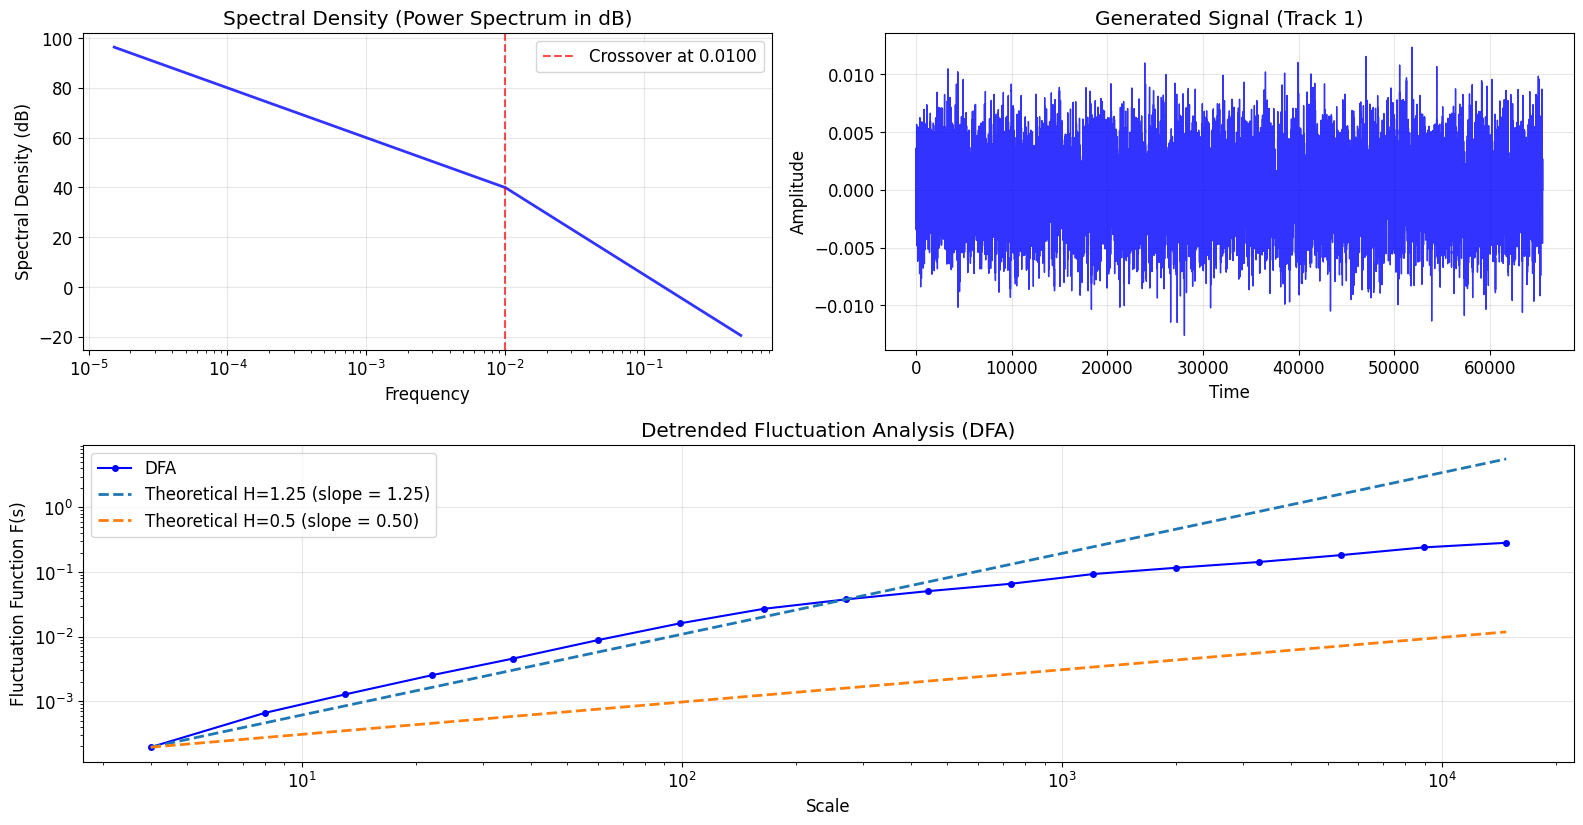

In [3]:
print("\n2. Two Hurst exponents with crossover")
signal2 = visualize_mfnoise(length=2**16, hurst=(1.25, 0.5), crossover_points=(100,), n_tracks=1)

### Test Case 2: Multiple tracks with multifractal noise


3. Multiple tracks with multifractal noise
Generating multifractal noise with parameters:
  Length: 65536
  Hurst exponents: (1.0, 0.5)
  Crossover points: (500,)
  Number of tracks: 1
  Normalize: True


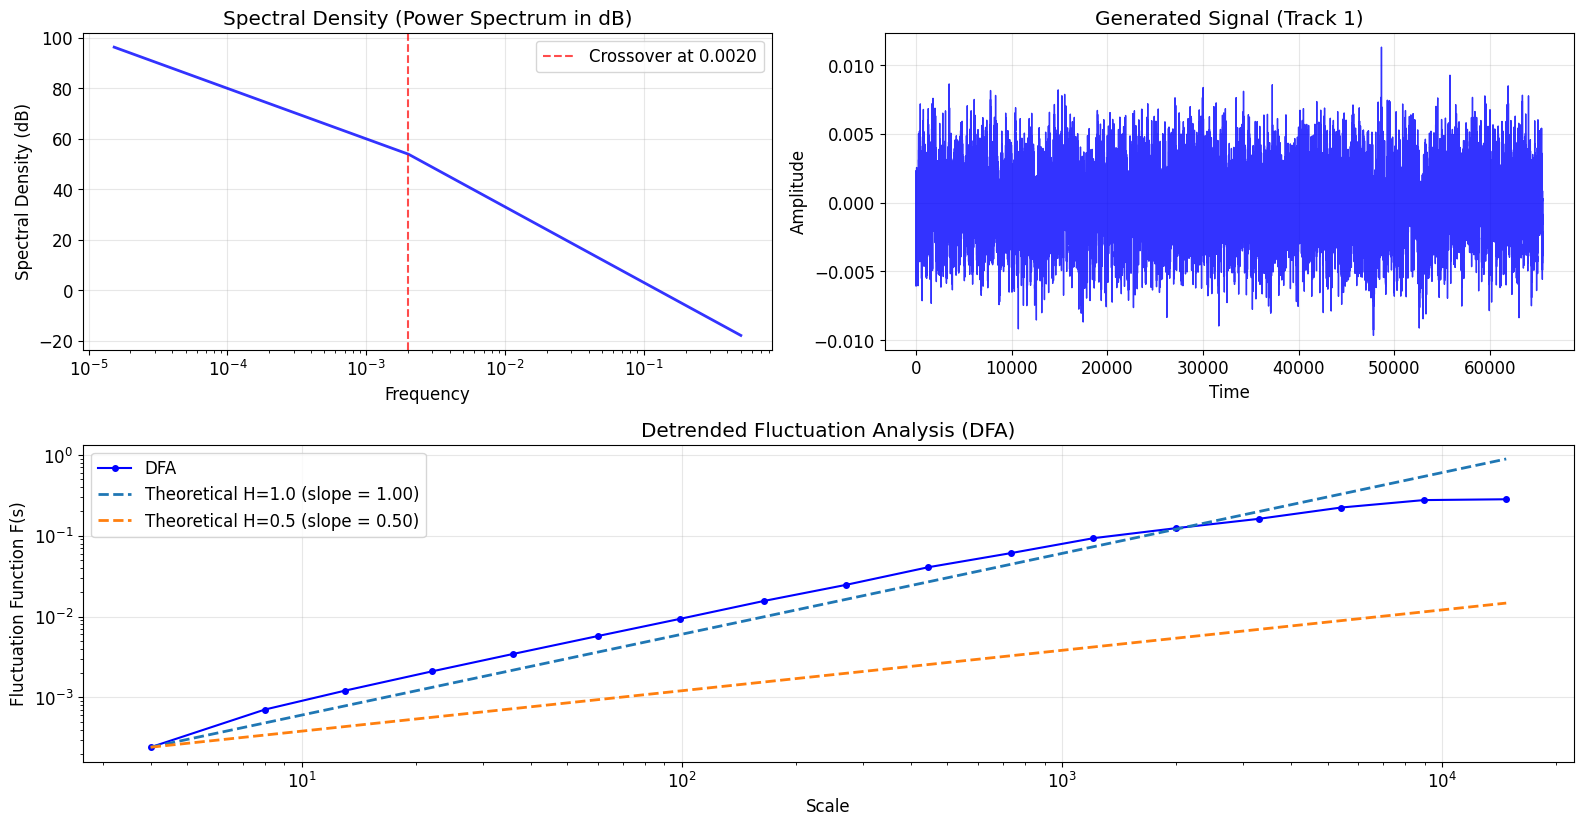

In [4]:
print("\n3. Multiple tracks with multifractal noise")
signal3 = visualize_mfnoise(length=2**16, hurst=(1.0, 0.5), crossover_points=(500,), n_tracks=1)

### Test Case 3: Single Hurst exponent (commented out in original)

Generating multifractal noise with parameters:
  Length: 65536
  Hurst exponents: 0.5
  Crossover points: ()
  Number of tracks: 1
  Normalize: True


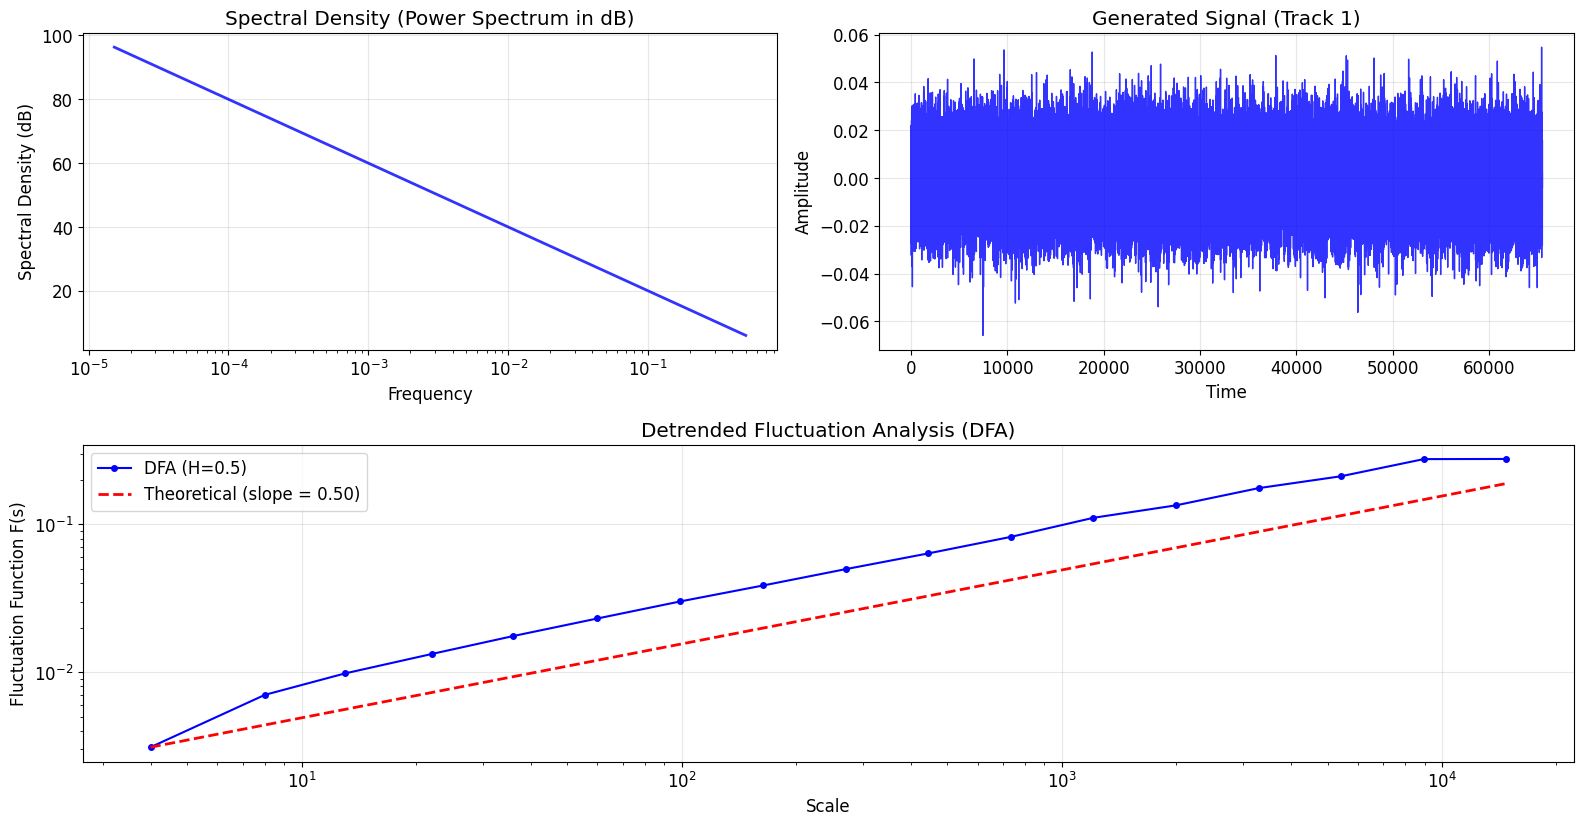

In [5]:
signal1 = visualize_mfnoise(length=2**16, hurst=0.5, crossover_points=(), n_tracks=1)